#  IA para Redes de Suministro 

👤 **Autor:** John Leonardo Vargas Mesa  
🔗 [LinkedIn](https://www.linkedin.com/in/leonardovargas/) | [GitHub](https://github.com/LeStark)  

## 📂 Repositorio en GitHub  
- 📓 **Notebooks:** [Acceder aquí](https://github.com/LeStark/Cursos/tree/main/02%20-%20IA4SC)  
- 📑 **Data sets:** [Acceder aquí](https://github.com/LeStark/Cursos/tree/main/00%20-%20Data/02%20-%20SC)  
---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
url_demanda = "https://raw.githubusercontent.com/LeStark/Cursos/refs/heads/main/00%20-%20Data/02%20-%20SC/Optimizacion%20Inventarios/Data_demanda.csv"
url_pedidos = "https://raw.githubusercontent.com/LeStark/Cursos/refs/heads/main/00%20-%20Data/02%20-%20SC/Optimizacion%20Inventarios/Data_pedidos.csv"

Data_demanda = pd.read_csv(url_demanda)
Data_pedidos = pd.read_csv(url_pedidos)


In [10]:
# --- Conversión de columnas a tipo datetime ---
Data_pedidos["Fecha Pedido"] = pd.to_datetime(Data_pedidos["Fecha Pedido"], errors="coerce")
Data_pedidos["Fecha Recepción"] = pd.to_datetime(Data_pedidos["Fecha Recepción"], errors="coerce")

# --- Verificación ---
print(Data_pedidos.dtypes)
print(Data_pedidos.head())



Producto                    int64
Fecha Pedido       datetime64[ns]
Fecha Recepción    datetime64[ns]
Cantidad                    int64
dtype: object
   Producto Fecha Pedido Fecha Recepción  Cantidad
0      1001   2024-02-12      2024-02-15       318
1      1001   2024-04-20      2024-04-25       474
2      1001   2024-04-24      2024-04-27       362
3      1001   2024-05-25      2024-05-30       439
4      1001   2024-05-28      2024-06-01       392


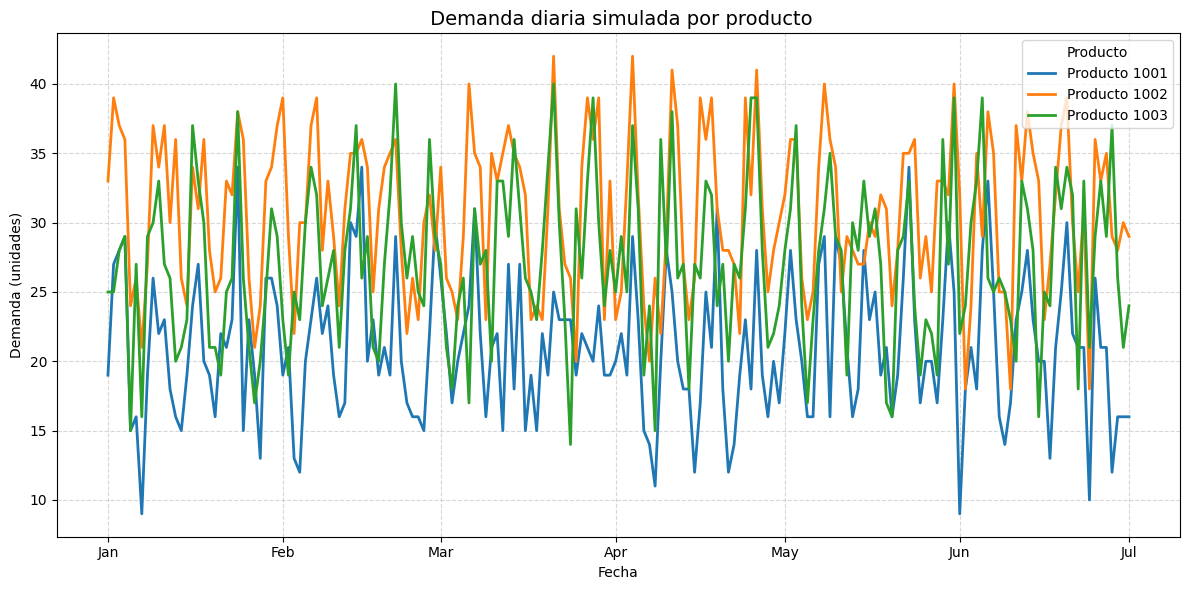

In [11]:
# --- Asegurarnos de que las fechas estén ordenadas ---
Data_demanda = Data_demanda.sort_values(["Producto", "Fecha"])

# --- Crear la figura ---
plt.figure(figsize=(12,6))

# --- Graficar demanda diaria para cada producto ---
for pid in Data_demanda["Producto"].unique():
    df_prod = Data_demanda[Data_demanda["Producto"] == pid]
    plt.plot(
        df_prod["Fecha"],
        df_prod["Demanda"],
        linewidth=2,
        label=f"Producto {pid}"
    )

# --- Personalización ---
plt.title(" Demanda diaria simulada por producto", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Demanda (unidades)")
plt.legend(title="Producto", loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar solo los meses en el eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()



#  Análisis estadístico de la demanda y el lead time

En este bloque se realiza el análisis descriptivo de las variables clave del sistema de inventario, con el propósito de comprender su comportamiento antes de aplicar modelos de optimización o simulación.

## 🔹 1️ Medias y desviaciones de la DEMANDA por producto
Se agrupan los registros de la base de datos `Data_demanda` por producto y se calculan los indicadores básicos:
- **Media_Demanda:** promedio de las unidades demandadas por día.
- **Desv_Demanda:** desviación estándar, que mide la variabilidad de la demanda.
- **Max_Demanda / Min_Demanda:** valores extremos observados.

Esto permite identificar productos con mayor volatilidad en la demanda, lo cual impacta directamente en el punto de reorden y el tamaño de pedido óptimo.

## 🔹 2️ Cálculo del LEAD TIME
A partir de la tabla `Data_pedidos`, se calcula el **Lead Time en días** como la diferencia entre la fecha de recepción y la fecha del pedido.  
Este indicador refleja el tiempo promedio que tarda el proveedor en entregar los productos.


## 🔹 3️ Medias y desviaciones del LEAD TIME por producto
De manera análoga, se agrupan los registros de `Data_pedidos` por producto y se calculan:
- **Media_LeadTime:** tiempo promedio de entrega.
- **Desv_LeadTime:** variabilidad del tiempo de entrega.
- **Máximo y mínimo Lead Time:** rangos de comportamiento del proveedor.

Con esta información se pueden determinar los **niveles de seguridad** y los **puntos de reorden (ROP)** considerando tanto la incertidumbre en la demanda como la del tiempo de reposición.


In [14]:


# --- 1️ Medias y desviaciones de la DEMANDA por producto ---
stats_demanda = (
    Data_demanda
    .groupby("Producto")["Demanda"]
    .agg(
        Media_Demanda="mean",
        Desv_Demanda="std",
        Max_Demanda="max",
        Min_Demanda="min"
    )
    .reset_index()
)

print(" Estadísticas de la demanda por producto:")
print(stats_demanda)


# --- 2️ Calcular Lead Time en días ---
Data_pedidos["Lead Time (días)"] = (
    Data_pedidos["Fecha Recepción"] - Data_pedidos["Fecha Pedido"]
).dt.days

# --- 3️ Medias y desviaciones del LEAD TIME por producto ---
stats_leadtime = (
    Data_pedidos
    .groupby("Producto")["Lead Time (días)"]
    .agg(
        Media_LeadTime="mean",
        Desv_LeadTime="std",
        Max_LeadTime="max",
        Min_LeadTime="min"
    )
    .reset_index()
)

print("\n Estadísticas del lead time por producto:")
print(stats_leadtime)


 Estadísticas de la demanda por producto:
   Producto  Media_Demanda  Desv_Demanda  Max_Demanda  Min_Demanda
0      1001      20.978022      5.110877           34            9
1      1002      30.670330      5.576301           42           18
2      1003      27.131868      5.813318           40           14

 Estadísticas del lead time por producto:
   Producto  Media_LeadTime  Desv_LeadTime  Max_LeadTime  Min_LeadTime
0      1001        3.625000       1.060660             5             2
1      1002        4.142857       1.951800             7             2
2      1003        4.714286       1.976047             7             2


In [15]:
# Costos por producto (ejemplo didáctico, ajusta a tu caso)
costos = {
    1001: {"unit_cost": 10.0, "holding_rate": 0.25, "ordering_cost": 22000.0,  "stockout_cost": 60.0},
    1002: {"unit_cost": 12.0, "holding_rate": 0.22, "ordering_cost": 32000.0, "stockout_cost": 50.0},
    1003: {"unit_cost": 8.0,  "holding_rate": 0.28, "ordering_cost": 16000.0,  "stockout_cost": 70.0},
}

def costos_producto(pid):
    c = costos[pid]
    h_diario = (c["holding_rate"] * c["unit_cost"]) / 365.0  # costo de posesión por unidad y día
    return h_diario, c["ordering_cost"], c["stockout_cost"]


In [ ]:

def simulador_inventario(
    producto_id: int,
    Data_demanda: pd.DataFrame,
    Data_pedidos: pd.DataFrame,
    Q: int,
    ROP: int,
    h: float = None,              # si None, se toma de 'costos'
    S: float = None,
    p: float = None,
    graficar: bool = True
):
    # --- Costos ---
    if h is None or S is None or p is None:
        h, S, p = costos_producto(producto_id)

    # --- Datos del producto ---
    df_demanda = Data_demanda[Data_demanda["Producto"] == producto_id].sort_values("Fecha").copy()
    lead_times = (
        Data_pedidos[Data_pedidos["Producto"] == producto_id]["Fecha Recepción"]
        - Data_pedidos[Data_pedidos["Producto"] == producto_id]["Fecha Pedido"]
    ).dt.days.values
    if len(lead_times) == 0:
        raise ValueError(f"No hay datos de lead time para el producto {producto_id}")

    # --- Inicialización ---
    dias = len(df_demanda)
    on_hand = ROP + Q // 2
    on_order = []  # (día_llegada, cantidad)

    cost_holding = 0.0
    cost_order   = 0.0
    cost_stock   = 0.0

    pedidos = 0
    stockout_dias = 0
    hist = []

    for t in range(dias):
        fecha   = df_demanda.iloc[t]["Fecha"]
        demanda = int(df_demanda.iloc[t]["Demanda"])

        # Llegadas
        recibo = 0
        llegadas_hoy = [q for (tl, q) in on_order if tl == t]
        if llegadas_hoy:
            recibo = sum(llegadas_hoy)
            on_hand += recibo
            on_order = [(tl, q) for (tl, q) in on_order if tl != t]

        # Venta / pérdida
        ventas = min(demanda, on_hand)
        perdida = demanda - ventas
        on_hand -= ventas

        # Posición
        inv_pos = on_hand + sum(q for _, q in on_order)

        # Pedido
        orden = 0
        if inv_pos <= ROP:
            L = int(np.random.choice(lead_times))
            on_order.append((t + L, Q))
            pedidos += 1
            orden = Q
            cost_order += S

        # Costos del día
        cost_holding += max(on_hand, 0) * h
        cost_stock   += perdida * p
        if perdida > 0:
            stockout_dias += 1

        total = cost_holding + cost_order + cost_stock

        hist.append({
            "Fecha": fecha, "Día": t,
            "Demanda": demanda, "Ventas": ventas, "Stockout_ud": perdida,
            "Inventario": on_hand, "Orden_Pedida": orden, "Recibo": recibo,
            "Inv_Pos": inv_pos, "Costo_Holding": cost_holding,
            "Costo_Ordering": cost_order, "Costo_Stockout": cost_stock,
            "Costo_Total": total
        })

    df_hist = pd.DataFrame(hist)
    nivel_servicio = 1 - df_hist["Stockout_ud"].sum() / (df_hist["Demanda"].sum() + 1e-9)

    resumen = {
        "Producto": producto_id,
        "Q": int(Q),
        "ROP": int(ROP),
        "h_diario": round(h, 4),
        "S": S,
        "p": p,
        "Nivel_servicio": round(nivel_servicio, 4),
        "Pedidos": pedidos,
        "Días_con_stockout": stockout_dias,
        "Costo_Holding": round(df_hist["Costo_Holding"].iloc[-1], 2),
        "Costo_Ordering": round(df_hist["Costo_Ordering"].iloc[-1], 2),
        "Costo_Stockout": round(df_hist["Costo_Stockout"].iloc[-1], 2),
        "Costo_Total": round(df_hist["Costo_Total"].iloc[-1], 2)
    }

    if graficar:
        plt.figure(figsize=(12,5))
        plt.plot(df_hist["Fecha"], df_hist["Inventario"], linewidth=2, label="Inventario")
        plt.scatter(df_hist.loc[df_hist["Orden_Pedida"]>0, "Fecha"],
                    df_hist.loc[df_hist["Orden_Pedida"]>0, "Inventario"],
                    marker="v", label="Pedido")
        plt.scatter(df_hist.loc[df_hist["Stockout_ud"]>0, "Fecha"],
                    [0]*int((df_hist["Stockout_ud"]>0).sum()),
                    color="red", s=25, label="Stockout")
        plt.axhline(ROP, color="gray", linestyle="--", label=f"ROP={ROP}")
        plt.title(f"Simulación Inventario (Q={Q}, ROP={ROP}) - Producto {producto_id}")
        plt.xlabel("Fecha"); plt.ylabel("Unidades"); plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        plt.tight_layout(); plt.show()

    return resumen, df_hist


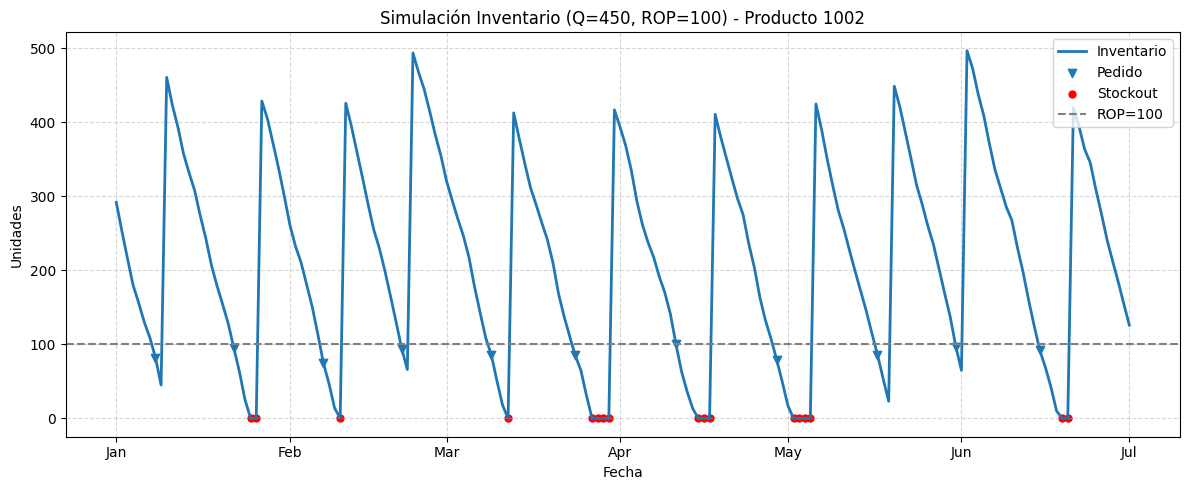

{'Producto': 1002, 'Q': 450, 'ROP': 100, 'h_diario': 0.0072, 'S': 32000.0, 'p': 50.0, 'Nivel_servicio': 0.9224, 'Pedidos': 11, 'Días_con_stockout': 17, 'Costo_Holding': 280.33, 'Costo_Ordering': 352000.0, 'Costo_Stockout': 21650.0, 'Costo_Total': 373930.33}


In [17]:
# Producto a simular
pid = 1002

# Política tentativa
Q_init = 450
ROP_init = 100

# a) Con gráfico
resumen, hist = simulador_inventario(pid, Data_demanda, Data_pedidos, Q_init, ROP_init, graficar=True)
print(resumen)


In [18]:
def grid_costos(pid, Q_vals, R_vals):
    rows = []
    for Q in Q_vals:
        for R in R_vals:
            res, _ = simulador_inventario(pid, Data_demanda, Data_pedidos, Q, R, graficar=False)
            rows.append(res)
    df = pd.DataFrame(rows)
    return df.sort_values("Costo_Total").reset_index(drop=True)

# Ejemplo:
df_grid = grid_costos(1001, Q_vals=range(3000, 24000, 1000), R_vals=range(50, 200, 50))
df_grid.head()


,Producto,Q,ROP,h_diario,S,p,Nivel_servicio,Pedidos,Días_con_stockout,Costo_Holding,Costo_Ordering,Costo_Stockout,Costo_Total
0,1001,8000,50,0.0068,22000.0,60.0,1.0,0,0,2649.73,0.0,0.0,2649.73
1,1001,8000,100,0.0068,22000.0,60.0,1.0,0,0,2712.06,0.0,0.0,2712.06
2,1001,8000,150,0.0068,22000.0,60.0,1.0,0,0,2774.39,0.0,0.0,2774.39
3,1001,9000,50,0.0068,22000.0,60.0,1.0,0,0,3273.02,0.0,0.0,3273.02
4,1001,9000,100,0.0068,22000.0,60.0,1.0,0,0,3335.35,0.0,0.0,3335.35


C:\Users\jlvar\AppData\Local\Temp\ipykernel_30780\3149709814.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_fmt = pivot.applymap(lambda v: formato_dinero(v) if pd.notnull(v) else "")
C:\Users\jlvar\AppData\Local\Temp\ipykernel_30780\3149709814.py:57: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jlvar\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


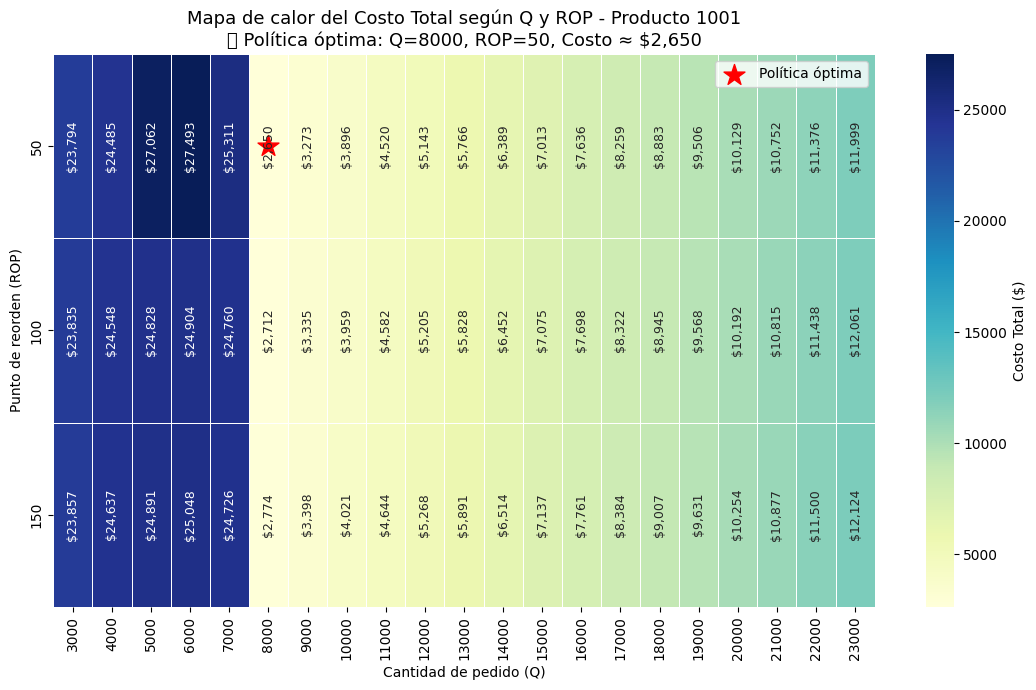

In [ ]:
# --- Crear tabla pivote ---
pivot = df_grid.pivot_table(
    index="ROP",
    columns="Q",
    values="Costo_Total",
    aggfunc="mean"
)

# --- Localizar el punto de costo mínimo ---
min_idx = df_grid["Costo_Total"].idxmin()
q_opt = df_grid.loc[min_idx, "Q"]
r_opt = df_grid.loc[min_idx, "ROP"]
min_cost = df_grid.loc[min_idx, "Costo_Total"]

# --- Formatear valores como dinero ---
def formato_dinero(x):
    return f"${x:,.0f}"

pivot_fmt = pivot.applymap(lambda v: formato_dinero(v) if pd.notnull(v) else "")

# --- Crear figura ---
plt.figure(figsize=(11,7))

# --- Heatmap con etiquetas verticales y formato monetario ---
ax = sns.heatmap(
    pivot,
    annot=pivot_fmt,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.4,
    cbar_kws={'label': 'Costo Total ($)'},
    annot_kws={"rotation": 90, "fontsize": 9, "va": "center", "ha": "center"}  # texto vertical
)

# --- Añadir marcador del punto óptimo ---
x_idx = list(pivot.columns).index(q_opt)
y_idx = list(pivot.index).index(r_opt)
plt.scatter(x_idx + 0.5, y_idx + 0.5, color="red", marker="*", s=250, label="Política óptima")

# --- Etiquetas y título ---
plt.title(
    f"Mapa de calor del Costo Total según Q y ROP - Producto 1001\n"
    f"Política óptima: Q={q_opt}, ROP={r_opt}, Costo ≈ {formato_dinero(min_cost)}",
    fontsize=13
)
plt.xlabel("Cantidad de pedido (Q)")
plt.ylabel("Punto de reorden (ROP)")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [20]:
def evaluar_politica(pid, Q, R, Data_demanda, Data_pedidos):
    res, _ = simulador_inventario(pid, Data_demanda, Data_pedidos, Q, R, graficar=False)
    return res["Costo_Total"]


In [ ]:
def local_search_QROP(pid, Data_demanda, Data_pedidos,
                      Q_inicial, R_inicial,
                      paso_Q=500, paso_R=50,
                      max_iter=50, verbose=True):
    """
    Búsqueda local simple para minimizar el costo total de inventario.
    """

    mejor_Q, mejor_R = Q_inicial, R_inicial
    mejor_costo = evaluar_politica(pid, mejor_Q, mejor_R, Data_demanda, Data_pedidos)

    if verbose:
        print(f"Inicio: Q={mejor_Q}, R={mejor_R}, Costo={mejor_costo:,.0f}")

    historia = [(mejor_Q, mejor_R, mejor_costo)]

    for i in range(max_iter):
        # Definir vecindad
        vecinos = [
            (mejor_Q + paso_Q, mejor_R),
            (mejor_Q - paso_Q, mejor_R),
            (mejor_Q, mejor_R + paso_R),
            (mejor_Q, mejor_R - paso_R)
        ]

        # Filtrar negativos o cero
        vecinos = [(Q, R) for Q, R in vecinos if Q > 0 and R > 0]

        # Evaluar vecinos
        costos = []
        for Q, R in vecinos:
            costo = evaluar_politica(pid, Q, R, Data_demanda, Data_pedidos)
            costos.append((Q, R, costo))

        # Seleccionar mejor vecino
        Q_best, R_best, costo_best = min(costos, key=lambda x: x[2])

        if costo_best < mejor_costo:
            mejor_Q, mejor_R, mejor_costo = Q_best, R_best, costo_best
            if verbose:
                print(f"Iter {i+1}: mejora → Q={mejor_Q}, R={mejor_R}, Costo={mejor_costo:,.0f}")
        else:
            if verbose:
                print(f"Iter {i+1}: sin mejora, fin de búsqueda")
            break

        historia.append((mejor_Q, mejor_R, mejor_costo))

    return mejor_Q, mejor_R, mejor_costo, historia


In [22]:
pid = 1001
Q0, R0 = 10000, 100  # valores iniciales razonables

Q_opt, R_opt, costo_opt, hist = local_search_QROP(
    pid, Data_demanda, Data_pedidos, Q0, R0,
    paso_Q=500, paso_R=25, max_iter=30
)

print(f"\n🔹 Óptimo encontrado: Q={Q_opt}, R={R_opt}, Costo ≈ ${costo_opt:,.0f}")


Inicio: Q=10000, R=100, Costo=3,959
Iter 1: mejora → Q=9500, R=100, Costo=3,647
Iter 2: mejora → Q=9000, R=100, Costo=3,335
Iter 3: mejora → Q=8500, R=100, Costo=3,024
Iter 4: mejora → Q=8000, R=100, Costo=2,712
Iter 5: mejora → Q=8000, R=75, Costo=2,681
Iter 6: mejora → Q=8000, R=50, Costo=2,650
Iter 7: mejora → Q=8000, R=25, Costo=2,619
Iter 8: sin mejora, fin de búsqueda

🔹 Óptimo encontrado: Q=8000, R=25, Costo ≈ $2,619


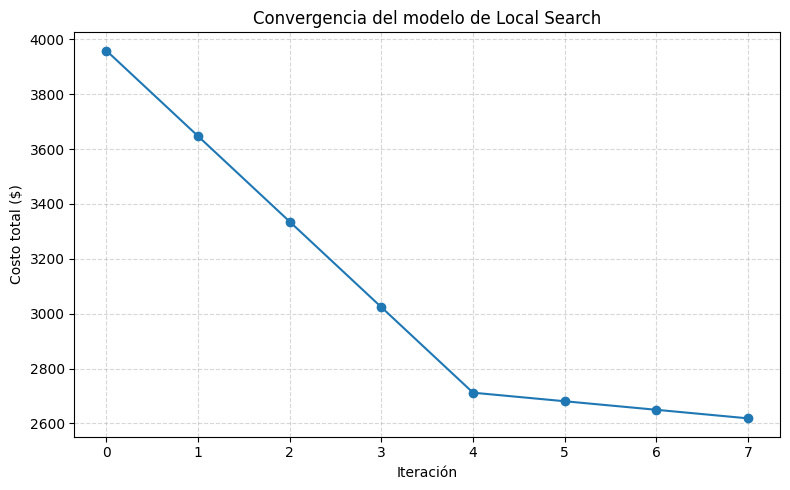

In [ ]:
df_hist = pd.DataFrame(hist, columns=["Q","ROP","Costo"])
plt.figure(figsize=(8,5))
plt.plot(df_hist["Costo"], marker="o")
plt.title("Convergencia del modelo de Local Search")
plt.xlabel("Iteración")
plt.ylabel("Costo total ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
def evaluar_promedio(pid, Q, R, Data_demanda, Data_pedidos, repeticiones=3):
    """
    Evalúa la política varias veces para suavizar ruido del simulador.
    Retorna el promedio del costo total.
    """
    costos = []
    for _ in range(repeticiones):
        res, _ = simulador_inventario(pid, Data_demanda, Data_pedidos, Q, R, graficar=False)
        costos.append(res["Costo_Total"])
    return np.mean(costos)

def local_search(pid, Data_demanda, Data_pedidos, Q_inicial, R_inicial,
                 paso_Q=500, paso_R=50, max_iter=20):
    """
    Búsqueda local simple con vecindad rectangular.
    """
    Q_act, R_act = Q_inicial, R_inicial
    costo_act = evaluar_promedio(pid, Q_act, R_act, Data_demanda, Data_pedidos)
    mejora = True
    while mejora:
        mejora = False
        vecinos = [
            (Q_act + paso_Q, R_act), (Q_act - paso_Q, R_act),
            (Q_act, R_act + paso_R), (Q_act, R_act - paso_R)
        ]
        vecinos = [(Q, R) for Q, R in vecinos if Q > 0 and R > 0]
        for Qv, Rv in vecinos:
            costo_v = evaluar_promedio(pid, Qv, Rv, Data_demanda, Data_pedidos)
            if costo_v < costo_act:
                Q_act, R_act, costo_act = Qv, Rv, costo_v
                mejora = True
                break  # moverse al mejor vecino encontrado (greedy)
    return Q_act, R_act, costo_act

def perturbar(Q, R, escala_Q=0.2, escala_R=0.2):
    """
    Genera una perturbación proporcional (±20% por defecto)
    """
    Qn = max(100, int(Q + np.random.uniform(-escala_Q, escala_Q) * Q))
    Rn = max(10, int(R + np.random.uniform(-escala_R, escala_R) * R))
    return Qn, Rn

def iterated_local_search(pid, Data_demanda, Data_pedidos,
                          Q_inicial, R_inicial,
                          iteraciones=20,
                          paso_Q=500, paso_R=50,
                          escala_perturbacion=0.2,
                          prob_aceptar_peor_inicial=0.1,
                          repeticiones_eval=2,
                          verbose=True):
    """
    Iterated Local Search (ILS) robusta con mejor_global fijo
    y enfriamiento exponencial de aceptación.
    """
    # --- Búsqueda local inicial ---
    Q_act, R_act, costo_act = local_search(pid, Data_demanda, Data_pedidos, Q_inicial, R_inicial, paso_Q, paso_R)
    mejor_Q, mejor_R, mejor_costo = Q_act, R_act, costo_act

    historia = [(0, Q_act, R_act, costo_act)]

    if verbose:
        print(f"Inicio: Q={Q_act}, R={R_act}, Costo={costo_act:,.0f}")

    # --- Bucle principal ---
    for i in range(1, iteraciones + 1):
        # Factor de enfriamiento (simulated annealing light)
        temp = 1 - i / iteraciones
        prob_aceptar_peor = prob_aceptar_peor_inicial * temp

        # Perturbar solución actual
        Qp, Rp = perturbar(Q_act, R_act, escala_perturbacion, escala_perturbacion)

        # Búsqueda local desde la perturbación
        Q_loc, R_loc, costo_loc = local_search(pid, Data_demanda, Data_pedidos, Qp, Rp, paso_Q, paso_R)

        # Decidir si se acepta
        mejora = costo_loc < costo_act
        delta = costo_loc - costo_act
        aceptar = mejora or (np.random.rand() < np.exp(-max(delta,0)/(mejor_costo*0.05)))  # enfriamiento suave

        if aceptar:
            Q_act, R_act, costo_act = Q_loc, R_loc, costo_loc
            if costo_act < mejor_costo:
                mejor_Q, mejor_R, mejor_costo = Q_act, R_act, costo_act
                if verbose:
                    print(f"Iter {i}: nuevo mejor global → Q={mejor_Q}, R={mejor_R}, Costo={mejor_costo:,.0f}")
            elif verbose:
                print(f"Iter {i}: aceptado peor (escape), costo={costo_act:,.0f}")
        else:
            if verbose:
                print(f"Iter {i}: rechazada solución peor ({costo_loc:,.0f})")

        historia.append((i, Q_act, R_act, costo_act))

    return mejor_Q, mejor_R, mejor_costo, historia




In [25]:
pid = 1001
Q0, R0 = 5000, 100

Q_opt, R_opt, costo_opt, hist = iterated_local_search(
    pid, Data_demanda, Data_pedidos,
    Q_inicial=Q0, R_inicial=R0,
    iteraciones=25,
    paso_Q=500, paso_R=25,
    escala_perturbacion=0.25,
    prob_aceptar_peor_inicial=0.1,
    repeticiones_eval=2,
    verbose=True
)

print(f"\n✅ Óptimo final encontrado:")
print(f"   Q = {Q_opt}")
print(f"   ROP = {R_opt}")
print(f"   Costo total ≈ ${costo_opt:,.0f}")


Inicio: Q=3000, R=100, Costo=23,815
Iter 1: nuevo mejor global → Q=2732, R=80, Costo=23,549
Iter 2: aceptado peor (escape), costo=23,616
Iter 3: aceptado peor (escape), costo=24,413
Iter 4: aceptado peor (escape), costo=24,506
Iter 5: aceptado peor (escape), costo=23,767
Iter 6: nuevo mejor global → Q=2553, R=85, Costo=23,379
Iter 7: aceptado peor (escape), costo=23,383
Iter 8: rechazada solución peor (45,222)
Iter 9: aceptado peor (escape), costo=23,670
Iter 10: aceptado peor (escape), costo=23,827
Iter 11: aceptado peor (escape), costo=23,595
Iter 12: aceptado peor (escape), costo=24,440
Iter 13: aceptado peor (escape), costo=24,724
Iter 14: aceptado peor (escape), costo=24,707
Iter 15: aceptado peor (escape), costo=24,342
Iter 16: aceptado peor (escape), costo=23,799
Iter 17: aceptado peor (escape), costo=23,891
Iter 18: aceptado peor (escape), costo=23,655
Iter 19: aceptado peor (escape), costo=23,816
Iter 20: aceptado peor (escape), costo=23,615
Iter 21: aceptado peor (escape), co

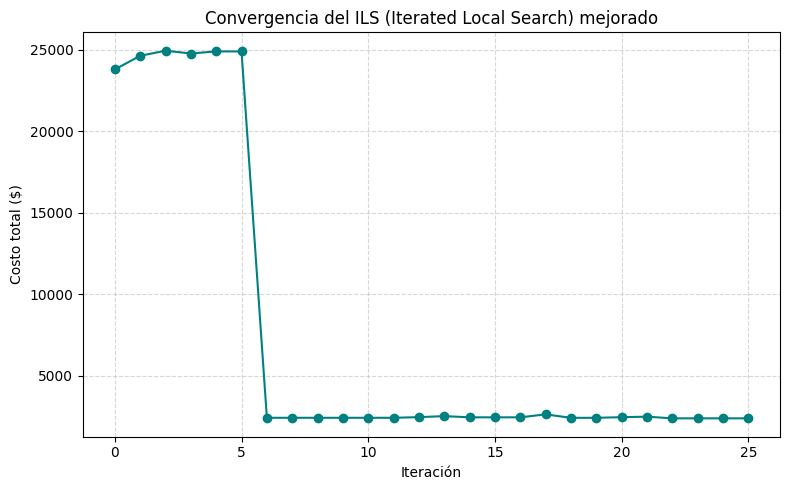

In [72]:
df_hist = pd.DataFrame(hist, columns=["Iteración","Q","ROP","Costo"])
plt.figure(figsize=(8,5))
plt.plot(df_hist["Iteración"], df_hist["Costo"], marker="o", color="teal")
plt.title("Convergencia del ILS (Iterated Local Search) mejorado")
plt.xlabel("Iteración")
plt.ylabel("Costo total ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
!pip install scikit-opt
from sko.PSO import PSO

   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.5/38.5 MB 28.8 MB/s eta 0:00:02
   ----------- ---------------------------- 11.5/38.5 MB 29.8 MB/s eta 0:00:01
   -------------------- ------------------- 19.7/38.5 MB 33.3 MB/s eta 0:00:01
   ---------------------------- ----------- 27.0/38.5 MB 33.5 MB/s eta 0:00:01
   --------------------------------- ------ 32.2/38.5 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------  38.3/38.5 MB 31.6 MB/s eta 0:00:01
   ---------------------------------------- 38.5/38.5 MB 30.3 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   --------------------------------------

In [ ]:
def objective_function(x):
    """
    Función objetivo para PSO.
    x: vector [Q, ROP]
    """
    Q, R = int(x[0]), int(x[1])

    if Q <= 0 or R <= 0:
        return 1e9  # penalización por valores inválidos

    try:
        res, _ = simulador_inventario(1001, Data_demanda, Data_pedidos, Q, R, graficar=False)
        cost = res["Costo_Total"]
    except Exception:
        cost = 1e9

    return cost


In [77]:
# Configurar el optimizador de partículas
pso = PSO(
    func=objective_function,
    n_dim=2,                # número de variables (Q y ROP)
    pop=30,                 # tamaño de la población
    max_iter=50,            # número de iteraciones
    lb=[100, 10],           # límites inferiores [Q, ROP]
    ub=[10000, 500],        # límites superiores [Q, ROP]
    w=0.8,                  # inercia (balance exploración/explotación)
    c1=1.5, c2=1.5          # factores cognitivo y social
)

# Entrenamiento
pso.run()


(array([7639.38001832,   10.43056304]), array([2374.24]))

In [78]:
best_Q, best_ROP = pso.gbest_x
best_cost = pso.gbest_y

print(f"🔹 Mejor solución encontrada:")
print(f"   Q   = {int(best_Q)}")
print(f"   ROP = {int(best_ROP)}")
print(f"   Costo total ≈ ${best_cost[0]:,.0f}")


🔹 Mejor solución encontrada:
   Q   = 7639
   ROP = 10
   Costo total ≈ $2,374


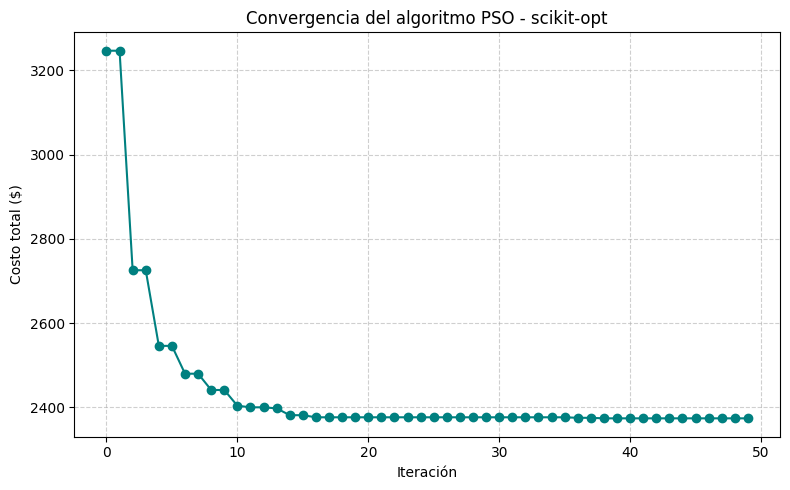

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(pso.gbest_y_hist, marker="o", color="teal")
plt.title("Convergencia del algoritmo PSO - scikit-opt")
plt.xlabel("Iteración")
plt.ylabel("Costo total ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


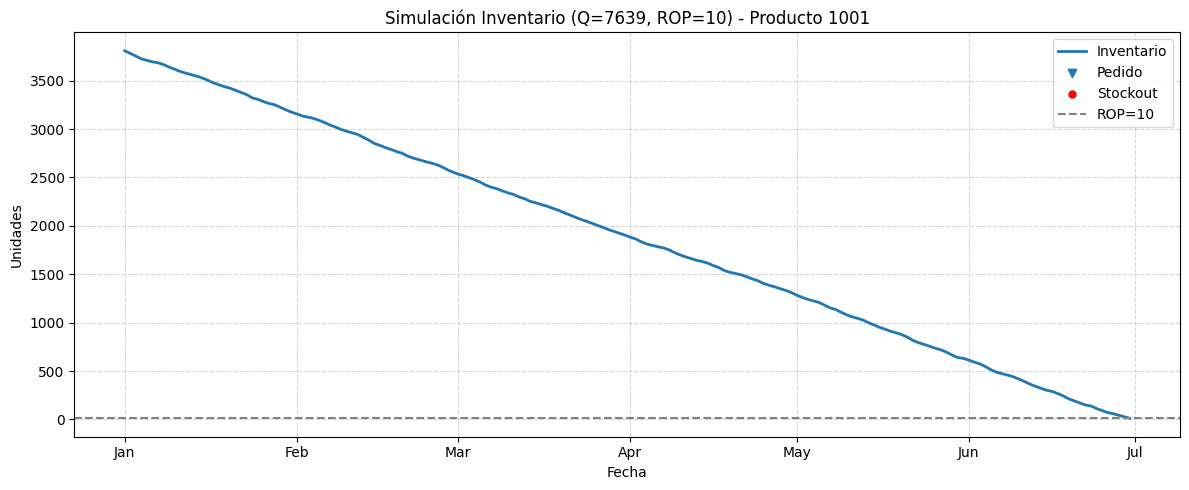

{'Producto': 1001, 'Q': 7639, 'ROP': 10, 'h_diario': 0.0068, 'S': 22000.0, 'p': 60.0, 'Nivel_servicio': 1.0, 'Pedidos': 0, 'Días_con_stockout': 0, 'Costo_Holding': 2374.24, 'Costo_Ordering': 0.0, 'Costo_Stockout': 0.0, 'Costo_Total': 2374.24}


In [80]:
resumen, hist = simulador_inventario(1001, Data_demanda, Data_pedidos,
                                     int(best_Q), int(best_ROP),
                                     graficar=True)
print(resumen)
